In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


The dataset

In [16]:
data = np.loadtxt("demo_logistic_regression.csv", delimiter=",", dtype=np.float64, skiprows=1)
X, y = data[:, :-1], data[:, -1].reshape((-1, 1))

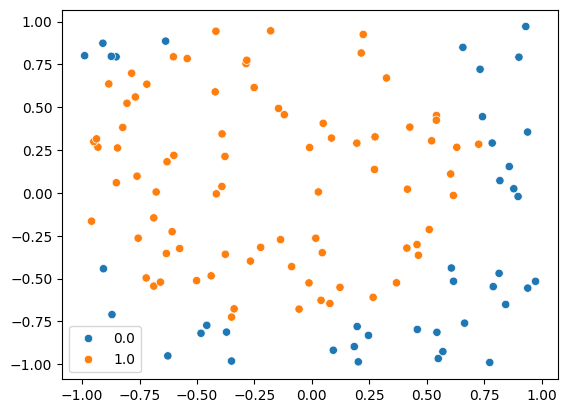

In [17]:
sns.scatterplot(x=X[:, 0], y=X[:,1], hue=y.flatten())   # the hue parameter is used to color the points based on their class labels
plt.show()

The Sigmoid Function

In [18]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

The Cross Entropy Loss Function

In [19]:
def loss(theta, X, y):
    h = sigmoid(np.dot(X, theta))
    cos = -(np.sum((y * np.log(h)) + (1 - y) * np.log(1 - h))) / len(y)
    return cos

The Gradient

In [20]:
def grad(theta, X, y):
    h = sigmoid(np.dot(X, theta))
    grad = np.dot(X.T, (h - y)) / len(y)
    return grad

The feature trick

In [21]:
def expand_features(x1, x2, power=2):
    # expand a 2D feature matrix to polynomial features up to the power.
    new_x = np.ones((x1.shape[0], 1))
    for i in range(1, power+1):
        for j in range(i+1):
             term = (x1 ** (i - j)) * (x2 ** j)
             new_x = np.c_[new_x, term]
            
    return new_x

In [22]:
def predict(theta, X):
    return (sigmoid(np.dot(X, theta)) > 0.5).astype(int).flatten()

Gradient Descent

In [23]:
def gradient_descent(X, y, theta, alpha, num_iters):
    m = len(y)
    costs = []

    for _ in range (num_iters):
        h = sigmoid(np.dot(X, theta))
        theta -= alpha * np.dot(X.T, (h - y)) / m
        costs.append(loss(theta, X, y))
    
    return theta, costs

Implement logistic regression

In [24]:
def logistic_regression(X, y, power,alpha, num_iters):
    expand_features(X[:, 0], X[:, 1], power)
    theta = np.zeros((X.shape[1], 1))
    theta, costs = gradient_descent(X, y, theta, alpha, num_iters)
    predicted = predict(theta, X)
    return predicted, theta, costs

Decide the polynomial power in the features, and the number of iterations

In [25]:
power, num_iters = 3, 1000
predicted, theta, costs = logistic_regression(X, y, power=power, alpha=1.5, num_iters=num_iters) 

In [26]:
print('The Accuracy is {:.2f} %'.format(sum(predicted == y.flatten()) / len(y) * 100))

The Accuracy is 66.67 %


In [27]:
def logistic_regression(X, y, power, alpha, num_iters):
    X_poly = expand_features(X[:, 0], X[:, 1], power)   # ✅ USE expanded features
    
    theta = np.zeros((X_poly.shape[1], 1))
    theta, costs = gradient_descent(X_poly, y, theta, alpha, num_iters)
    
    predicted = predict(theta, X_poly)
    return predicted, theta, costs, X_poly

In [28]:
def plot_decision_boundary(X, y, theta, power):
    u = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)
    v = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
    
    z = np.zeros((len(u), len(v)))

    for i in range(len(u)):
        for j in range(len(v)):
            features = expand_features(
                np.array([u[i]]),
                np.array([v[j]]),
                power
            )
            z[i,j] = np.dot(features, theta)

    z = z.T

    # Plot boundary
    plt.contour(u, v, z, levels=[0], colors='darkred')

    # Plot data
    plt.scatter(X[:,0], X[:,1], c=y.flatten(), cmap='coolwarm')

    plt.title("Decision Boundary")
    plt.show()

# again

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load your uploaded dataset
data = pd.read_csv('microchip_test_dataset.csv')

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

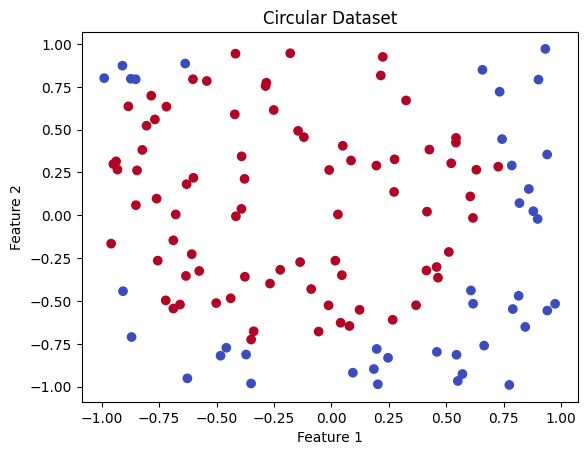

In [30]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Circular Dataset")
plt.show()

In [31]:
def map_features(X1, X2, degree=6):
    out = [np.ones(X1.shape[0])]
    
    for i in range(1, degree+1):
        for j in range(i+1):
            out.append((X1**(i-j)) * (X2**j))
    
    return np.stack(out, axis=1)

X_mapped = map_features(X[:,0], X[:,1], degree=6)

In [32]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

with regularization

In [33]:
def train_logistic(X, y, lr=0.1, epochs=1000, lam=1):
    
    m, n = X.shape
    w = np.zeros(n)
    losses = []
    
    for i in range(epochs):
        z = np.dot(X, w)
        y_hat = sigmoid(z)
        
        # LOSS (L2 REG)
        bce = - (1/m) * np.sum(
            y*np.log(y_hat+1e-9) + (1-y)*np.log(1-y_hat+1e-9)
        )
        reg = (lam/(2*m)) * np.sum(w[1:]**2)   # exclude bias
        
        loss = bce + reg
        losses.append(loss)
        
        # GRADIENT
        dw = (1/m) * np.dot(X.T, (y_hat - y))
        dw[1:] += (lam/m) * w[1:]
        
        # UPDATE
        w -= lr * dw
    
    return w, losses

In [34]:
w, losses = train_logistic(X_mapped, y, lr=0.5, epochs=2000, lam=1)

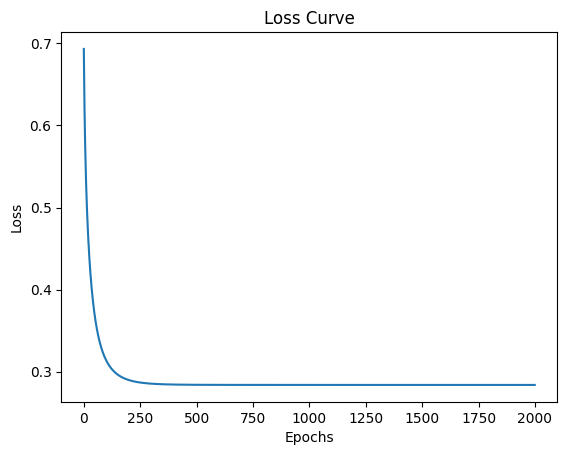

In [35]:
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

C:\Users\akhul\AppData\Local\Temp\ipykernel_17276\916483169.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z[i,j] = np.dot(mapped, w)


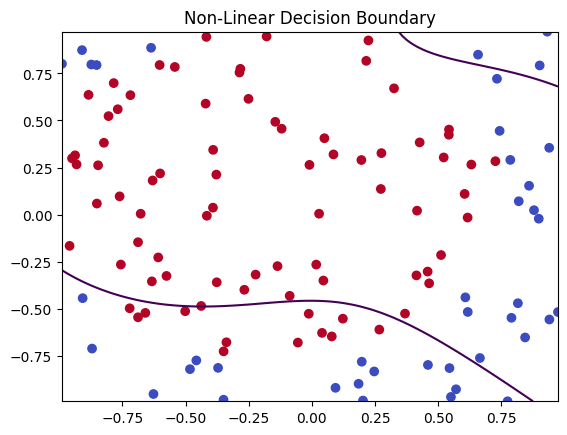

In [36]:
# before regularization


np.random.seed(42)
w_init = np.random.randn(X_mapped.shape[1])

plot_boundary(w_init, X, y)

In [37]:
def plot_boundary(w, X, y):
    
    u = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    v = np.linspace(X[:,1].min(), X[:,1].max(), 100)
    
    z = np.zeros((len(u), len(v)))
    
    for i in range(len(u)):
        for j in range(len(v)):
            mapped = map_features(
                np.array([u[i]]), 
                np.array([v[j]])
            )
            z[i,j] = np.dot(mapped, w)
    
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
    
    # contour = decision boundary
    plt.contour(u, v, z.T, levels=[0])
    
    plt.title("Non-Linear Decision Boundary")
    plt.show()

C:\Users\akhul\AppData\Local\Temp\ipykernel_17276\916483169.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z[i,j] = np.dot(mapped, w)


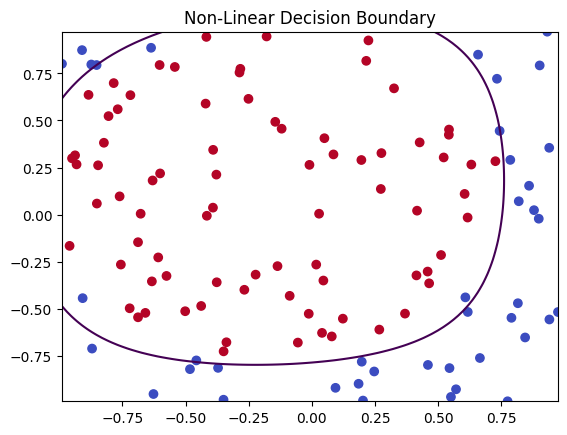

In [38]:
plot_boundary(w, X, y)